In [1]:
import numpy as np
from math import exp,log,prod
import matplotlib.pyplot as plt


## divide data 60-20-20

In [2]:
with open('dane.data', 'r') as data, open('training.data', 'w') as training, open('validation.data', 'w') as validation, open('testing.data', 'w') as testing:
    for line in data:
        random_value = np.random.rand()
        if random_value < 0.6:  # 60% chance to go to training
            training.write(line)
        elif random_value < 0.8:  # 20% chance to go to validation
            validation.write(line)
        else:
            testing.write(line)

## divide 50-30-20

In [3]:
with open('dane.data', 'r') as data, open('training.data', 'w') as training, open('validation.data', 'w') as validation, open('testing.data', 'w') as testing:
    for line in data:
        random_value = np.random.rand()
        if random_value < 0.8:  
            training.write(line)
        elif random_value < 0.9:  
            validation.write(line)
        else:
            testing.write(line)

## read_data

In [4]:
def load_data(filename):
    data = np.loadtxt(filename, delimiter='\t')
    X = data[:, :-1]
    y = data[:, -1]
    return X, y


In [5]:
X_train, y_train = load_data('training.data')
X_val, y_val = load_data('validation.data')
X_test, y_test = load_data('testing.data')
mean=X_train.mean(axis=0)
std = X_train.std(axis=0)
min_val = X_train.min(axis=0)
max_val = X_train.max(axis=0)

## scaling

In [6]:
# MIN-MAX SCALING
def scale(X):
    X_scaled = (X - min_val) / (max_val - min_val)
    return X_scaled

In [7]:
# MIN-MAX 2 SCALING
def scale(X):
    X_scaled = (X - mean) / (max_val - min_val)
    return X_scaled

In [8]:
# STANDARIZATION

def scale(X):
    return (X-mean)/std

In [9]:
X_train=scale(X_train)
X_val=scale(X_val)
X_test=scale(X_test)

## different loss functions

In [10]:
# square
def loss_function(a,y):
    return (a-y)**2

In [11]:
# absolute
def loss_function(a,y):
    return abs(a-y)

## base functions

In [12]:
# no change
def basis(x):
    return x

In [13]:
# square all values
def basis(x):
    return [val**2 for val in x]

In [14]:
def basis(x):
    return [prod(x)]

In [15]:
def basis(x):
    x_mean= sum(x)/8
    s=5
    return [-exp((val-x_mean)**2/s**2) for val in x]

In [16]:
def basis(x):
    return [exp(-val**2) for val in x]

In [17]:
def basis(x):
    return [np.sin(val) for val in x] + [np.cos(val) for val in x]

In [18]:
def remodel(X):
    new_X=[basis(x) for x in X]
    return np.array(new_X)

In [19]:
X_train_r=remodel(X_train)
X_val_r=remodel(X_val)
X_test_r=remodel(X_test)

## Validate

In [20]:
possible_lambdas = [0.01,0.1 , 1 , 10, 20, 30, 100, 1000]

## Regression

In [21]:
def analytic_solution(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    X = np.c_[np.ones(X.shape[0]), X]
    res = np.linalg.inv(X.T @ X) @ X.T @ y
    return res

In [22]:
def analytic_solution_ridge(X: np.ndarray, y: np.ndarray, lam=10) -> np.ndarray:
    X = np.c_[np.ones(X.shape[0]), X]
    d = X.shape[1]
    res = np.linalg.inv(X.T @ X + lam*np.eye(d)) @ X.T @ y
    return res

## ANALYTICAL_SOLVE

In [ ]:

lambdas=[]
errors=[]
def validate(X,y):
    smallest_error=float("inf")
    best_solution=None
    for l in possible_lambdas:
        try:
            solution = analytic_solution_ridge(X, y,lam=l)
        except:
            print(f"singular matrix for lambda = {l}")
        error = 0
        X_val_bias = np.c_[np.ones(X_val_r.shape[0]), X_val_r]
        y_pred = X_val_bias @ solution
        
        error = np.mean((loss_function(y_pred,y_val)))
        lambdas.append(l)
        errors.append(error)
        if error<smallest_error:
            smallest_error=error
            best_solution=solution
    return best_solution

## Gradient

In [24]:
# modify here for different learning rate
eta = 0.00005

In [25]:
# gradient descent for ridge regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @ (X @ theta - y)
    grad[1:] +=lamb * theta[1:]
    return eta*grad

In [26]:
# gradient descent for lasso regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @(X @ theta - y)
    grad[1:]+= lamb*np.sign(theta[1:])
    return eta * grad

In [27]:
# gradient descent for elastic net regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @(X @ theta - y)
    grad[1:]+= lamb*np.sign(theta[1:])
    grad[1:] +=lamb * theta[1:]
    return eta * grad


In [28]:
def gradient_descent(X, y, lamb, num_iterations=100):
    X = np.c_[np.ones(X.shape[0]), X]
    theta = np.random.random(X.shape[1]) 
    for _ in range(num_iterations):
        theta -= compute_theta(theta,X,y,lamb)
    return theta

## validate with gradient

In [ ]:
def validate(X_train_r, y_train):
    smallest_error = float("inf")
    best_lambda = None
    best_solution = None
    lambdas = []
    errors = []

    for l in possible_lambdas:
        solution = gradient_descent(X_train_r, y_train, l)
        X_val_bias = np.c_[np.ones(X_val_r.shape[0]), X_val_r]
        y_pred = X_val_bias @ solution
        error = np.mean(loss_function(y_pred, y_val))

        lambdas.append(l)
        errors.append(error)

        if error < smallest_error:
            smallest_error = error
            best_lambda = l
            best_solution = solution

    return best_solution

## TEST_FOUND_DATA

In [30]:
def test(X,y):
    best_solution=validate(X_val_r,y_val)
    error = 0
    for i in range(X.shape[0]):
        x = np.insert(X[i], 0, 1)

        try:
            a = best_solution @ x
            error += loss_function(a, y[i])
        except:
            print(best_solution)
            print(x)
        
    error /= X.shape[0]
    return error

## model learning curve

error = 65.81193065141419
for fraction = 0.01
error = 109.98014905915427
for fraction = 0.02
error = 106.08583451269833
for fraction = 0.03
error = 91.303933815641
for fraction = 0.125
error = 99.93607857269879
for fraction = 0.625
error = 98.76588252594023
for fraction = 1


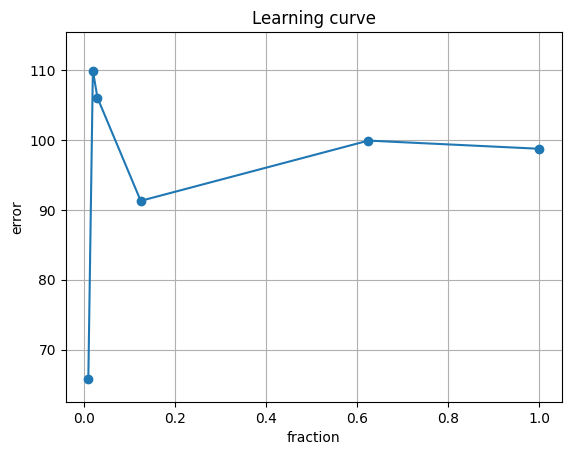

In [31]:
fractions=[
    0.01,0.02,0.03,0.125,0.625,1]
res_errors=[]
for f in fractions:
    #  at least 1 line
    n = max(1, int(len(X_train_r) * f))
    indices = np.random.choice(len(X_train_r), size=n, replace=False)
    X = X_train_r[indices]
    y = y_train[indices]
    res_errors.append(test(X, y))
    print(f'error = {res_errors[-1]}')
    print(f'for fraction = {f}')
plt.plot(fractions, res_errors, marker='o')
plt.xlabel("fraction")
plt.ylabel("error")
plt.title("Learning curve")
plt.ylim(min(res_errors)*0.95, max(res_errors)*1.05)
plt.grid()
plt.show()

## Random run summarized

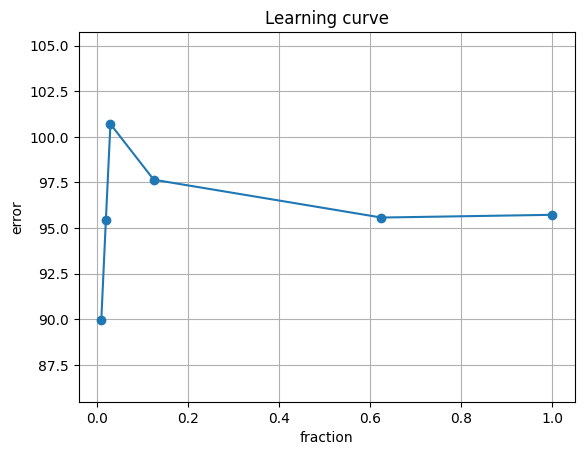

for fraction 0.01:
Average error: 89.98269924638942
for fraction 0.02:
Average error: 95.45090102632898
for fraction 0.03:
Average error: 100.70305549700853
for fraction 0.125:
Average error: 97.65129744542017
for fraction 0.625:
Average error: 95.57663213744448
for fraction 1:
Average error: 95.72637768612648


In [32]:
iters=10
fractions=[
    0.01,0.02,0.03,0.125,0.625,1]
res_errors=[0 for _ in range(6)]
for i in range(iters):
    with open('dane.data', 'r') as data, open('training.data', 'w') as training, open('validation.data', 'w') as validation, open('testing.data', 'w') as testing:
        for line in data:
            random_value = np.random.rand()
            if random_value < 0.6:  # 60% chance to go to training
                training.write(line)
            elif random_value < 0.8:  # 20% chance to go to validation
                validation.write(line)
            else:
                testing.write(line)

    X_train, y_train = load_data('training.data')
    X_val, y_val = load_data('validation.data')
    X_test, y_test = load_data('testing.data')
    mean=X_train.mean(axis=0)
    std = X_train.std(axis=0)
    min_val = X_train.min(axis=0)
    max_val = X_train.max(axis=0)
    X_train=scale(X_train)
    X_val=scale(X_val)
    X_test=scale(X_test)
    X_train_r=remodel(X_train)
    X_val_r=remodel(X_val)
    X_test_r=remodel(X_test)

    for j in range(len(fractions)):
        #  at least 1 line
        n = max(1, int(len(X_train_r) * fractions[j]))
        indices = np.random.choice(len(X_train_r), size=n, replace=False)
        X = X_train_r[indices]
        y = y_train[indices]
        res_errors[j]+=(test(X, y))
res_errors=[val/iters for val in res_errors]
plt.plot(fractions, res_errors, marker='o')
plt.xlabel("fraction")
plt.ylabel("error")
plt.title("Learning curve")
plt.ylim(min(res_errors)*0.95, max(res_errors)*1.05)
plt.grid()
plt.show()
for i in range(len(fractions)):
    print(f"for fraction {fractions[i]}:")
    print(f"Average error: {res_errors[i]}")